# **Assignment 3**

## **Task 0**

In [13]:
#a
!pip install ollama

import ollama

from ollama import chat
from ollama import ChatResponse

#b
response: ChatResponse = chat(model='gemma3:270m', messages=[
  {
    'role': 'user',
    'content': 'Why is the sky blue? Keep it short.',
  },
])

print(response.message.content)

The sky is blue because of a phenomenon called Rayleigh scattering. Sunlight is made up of all the colors of the rainbow. When sunlight hits the Earth's atmosphere, it interacts with these colors. The blue and violet light have shorter wavelengths than the other colors, so they are scattered more effectively by the air molecules. This scattering causes the sky to appear blue.



In [14]:
#c
response: ChatResponse = chat(model='gemma3:4b', messages=[
  {
    'role': 'user',
    'content': 'Why are sunsets red? Keep it short.',
  },
])

print(response.message.content)

Sunsets are red because of a phenomenon called Rayleigh scattering. When sunlight hits the atmosphere, shorter wavelengths (like blue and violet) are scattered away, leaving the longer wavelengths (red and orange) to reach our eyes directly. 

Essentially, the atmosphere is filtering out the blue light, leaving us with a red sunset!


## **Task 1**

In [30]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/sippohippo/PythonForBusinessInt2026/refs/heads/main/assignments/data/emails.csv", sep=";")

#a
def classify_email(headline):
    headline = headline.lower()
    spam_keywords = ["won", "free", "claim", "hot", "singles", "inheritance", "transfer", "urgent"]
    work_keywords = ["report", "project", "meeting", "manuscript", "performance", "review"]

    if any(word in headline for word in spam_keywords):
        return "spam"
    elif any(word in headline for word in work_keywords):
        return "work"
    else:
        return "unknown"

df["classification"] = df["headline"].apply(classify_email)

display(df)

,headline,classification
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,work
5,"Q3 budget report attached, please review by Fr...",work
6,Reminder: Annual performance review scheduled ...,work
7,"Updated draft of the manuscript, comments welcome",work
8,Quick question about last week,unknown
9,Following up,unknown


In [27]:
#b Using gemma3:270m
def classify_email_llm(headline, model):
    response = ollama.chat(model=model, messages=[
        {"role": "user", "content": (
            f"Classify this email headline as exactly one of: spam, work, or unknown. "
            f"Use these keywords as guidance:\n"
            f"spam: won, free, claim, hot, singles, inheritance, transfer, urgent\n"
            f"work: report, project, meeting, manuscript, performance, review\n"
            f"If you can't decide between spam and work, return unknown.\n"
            f"Reply with only the single word classification, nothing else.\n\n"
            f"Headline: {headline}"
        )}
    ])
    return response["message"]["content"].strip().lower()

df["gemma3_270m"] = df["headline"].apply(lambda x: classify_email_llm(x, "gemma3:270m"))

display(df[["headline", "classification", "gemma3_270m"]])

,headline,classification,gemma3_270m
0,URGENT: Your account will be suspended within ...,spam,work
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,unknown
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,work
4,Meeting agenda for Thursday's project review,work,unknown
5,"Q3 budget report attached, please review by Fr...",work,spam
6,Reminder: Annual performance review scheduled ...,work,spam
7,"Updated draft of the manuscript, comments welcome",work,spam
8,Quick question about last week,unknown,spam
9,Following up,unknown,work


In [28]:
#c Using gemma3:4b
df["gemma3_4b"] = df["headline"].apply(lambda x: classify_email_llm(x, "gemma3:4b"))

display(df[["headline", "classification", "gemma3_270m", "gemma3_4b"]])

,headline,classification,gemma3_270m,gemma3_4b
0,URGENT: Your account will be suspended within ...,spam,work,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,unknown,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,work,spam
4,Meeting agenda for Thursday's project review,work,unknown,work
5,"Q3 budget report attached, please review by Fr...",work,spam,work
6,Reminder: Annual performance review scheduled ...,work,spam,work
7,"Updated draft of the manuscript, comments welcome",work,spam,work
8,Quick question about last week,unknown,spam,unknown
9,Following up,unknown,work,unknown


In [29]:
#d Repeat both models 3 times and store results
results = df[["headline"]].copy()

for i in range(1, 4):
    results[f"270m_run{i}"] = df["headline"].apply(lambda x: classify_email_llm(x, "gemma3:270m"))
    results[f"4b_run{i}"]   = df["headline"].apply(lambda x: classify_email_llm(x, "gemma3:4b"))

display(results)

,headline,270m_run1,4b_run1,270m_run2,4b_run2,270m_run3,4b_run3
0,URGENT: Your account will be suspended within ...,spam,spam,spam,spam,work,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,work,spam,unknown,spam,work,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,spam,unknown,spam,work,spam
4,Meeting agenda for Thursday's project review,unknown,work,unknown,work,unknown,work
5,"Q3 budget report attached, please review by Fr...",spam,work,spam,work,spam,work
6,Reminder: Annual performance review scheduled ...,spam,work,work,work,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work,spam,work,spam,work
8,Quick question about last week,spam,unknown,spam,unknown,spam,unknown
9,Following up,unknown,unknown,unknown,unknown,unknown,unknown


### *Comparison*
So, the 270m version was very unreliable and inconsistent. Which I am a bit surprised by, the prompt is quite clear and it shouldn't be this difficult to classify these. The 4b model performed in the way I expected a model to perform as it was correct and consistent. Understandably 4b was also slightly slower in my experience.

# **Task 2**

In [33]:
import json

df = pd.read_csv("https://raw.githubusercontent.com/sippohippo/PythonForBusinessInt2026/refs/heads/main/assignments/data/news.csv", sep=";")

#a Classification function with JSON
def classify_news(headline):
    headline_lower = headline.lower()

    topic_keywords = {
        "earnings":       ["earnings", "revenue", "profit", "forecast", "estimates", "quarterly"],
        "mergers":        ["acquire", "merger", "takeover", "deal", "talks"],
        "regulation":     ["regulators", "compliance", "licence", "rules", "block", "act", "fsa"],
        "macroeconomics": ["inflation", "interest rates", "borrowing", "eurozone", "financing"]
    }

    positive_keywords = ["beats", "surges", "steady", "grants", "cools", "easing", "expanded"]
    negative_keywords = ["misses", "weak", "block", "raise costs", "weigh", "climb"]

    topic = "unknown"
    for t, keywords in topic_keywords.items():
        if any(word in headline_lower for word in keywords):
            topic = t
            break

    if any(word in headline_lower for word in positive_keywords):
        sentiment = "positive"
    elif any(word in headline_lower for word in negative_keywords):
        sentiment = "negative"
    else:
        sentiment = "neutral"

    return json.dumps({"topic": topic, "sentiment": sentiment})

df["classification"] = df["headline"].apply(classify_news)

display(df)

,headline,classification
0,Nordion Industries beats Q1 earnings estimates...,"{""topic"": ""earnings"", ""sentiment"": ""positive""}"
1,Helvora Pharmaceuticals misses earnings foreca...,"{""topic"": ""earnings"", ""sentiment"": ""negative""}"
2,"Aurelis Bank reports steady quarterly profit, ...","{""topic"": ""earnings"", ""sentiment"": ""positive""}"
3,Veridyne Logistics to acquire rival Trantec in...,"{""topic"": ""mergers"", ""sentiment"": ""neutral""}"
4,Antitrust regulators block proposed merger bet...,"{""topic"": ""mergers"", ""sentiment"": ""negative""}"
5,Kestrel Semiconductor confirms early-stage mer...,"{""topic"": ""mergers"", ""sentiment"": ""neutral""}"
6,New EU AI Act compliance rules expected to rai...,"{""topic"": ""regulation"", ""sentiment"": ""negative""}"
7,Finnish FSA grants Norvik Capital expanded lic...,"{""topic"": ""regulation"", ""sentiment"": ""positive""}"
8,"Eurozone inflation cools to 2.1%, easing press...","{""topic"": ""macroeconomics"", ""sentiment"": ""posi..."
9,Rising interest rates weigh on Tessaro Real Es...,"{""topic"": ""macroeconomics"", ""sentiment"": ""nega..."


In [36]:
#b Classify with gemma3:4b
def classify_news_llm(headline, model):
    response = ollama.chat(model=model, messages=[
        {"role": "user", "content": (
            f"Classify this financial news headline by topic and sentiment.\n"
            f"Topic must be exactly one of: earnings, mergers, regulation, macroeconomics\n"
            f"Sentiment must be exactly one of: positive, negative, neutral\n"
            f"Reply only with a JSON object in this exact format, nothing else:\n"
            f"{{\"topic\": \"...\", \"sentiment\": \"...\"}}\n\n"
            f"Headline: {headline}"
        )}
    ])
    return response["message"]["content"].strip()

raw_results = df["headline"].apply(lambda x: classify_news_llm(x, "gemma3:4b"))

df["topic"]     = raw_results.apply(lambda x: json.loads(x)["topic"])
df["sentiment"] = raw_results.apply(lambda x: json.loads(x)["sentiment"])

display(df[["headline", "topic", "sentiment"]])

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### *Subtask c (Claude)*

| Headline | Topic | Sentiment |
|----------|-------|-----------|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | neutral |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

Here Claude is a bit more inaccurate than Gemma3:4b regarding the sentiment, but more accurate regarding the topic (I would say headline 4 can be rightfully classified as both regulation/mergers). I can notice that Claude is more wiling to assign a neutral sentiment to the headlines, while Gemma only classifies one as neutral. But overall by the tiniest of margins, Gemma takes the cake i think since the only divergence from a) i can see with Gemma is changing one positive to neutral and one merger to regulation. Both were pretty good at this, the differences in answers can be written up as ambiguity in the headlines. I assume the reason Gemma3:4b outperformed Claude by this small bit is because it is maybe an overall more robust model than Sonnet 4.6.

# **Task 3**

In [50]:
import requests
import zipfile
import io
import matplotlib.pyplot as plt
import seaborn as sns

# Downloading the file from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))
zip_file.extractall("data")

#a Load bank-additional and some basic info
df = pd.read_csv("data/bank-additional/bank-additional.csv", sep=";")

print(df.shape)
print(df.dtypes)
display(df.head())
display(df.describe())

(4119, 21)
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


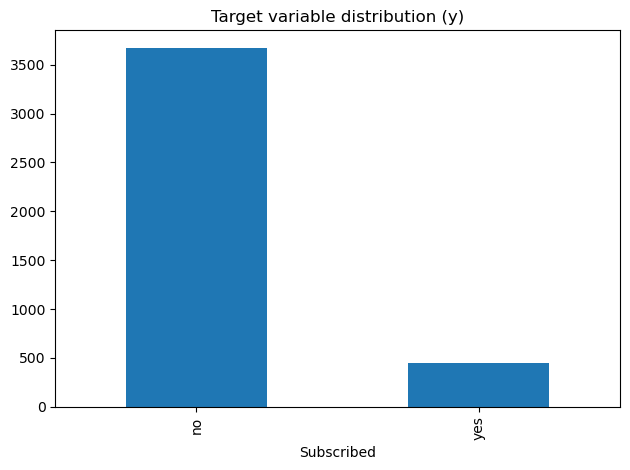

In [51]:
# Target variable distribution
df["y"].value_counts().plot(kind="bar")
plt.title("Target variable distribution (y)")
plt.xlabel("Subscribed")
plt.tight_layout()
plt.show()

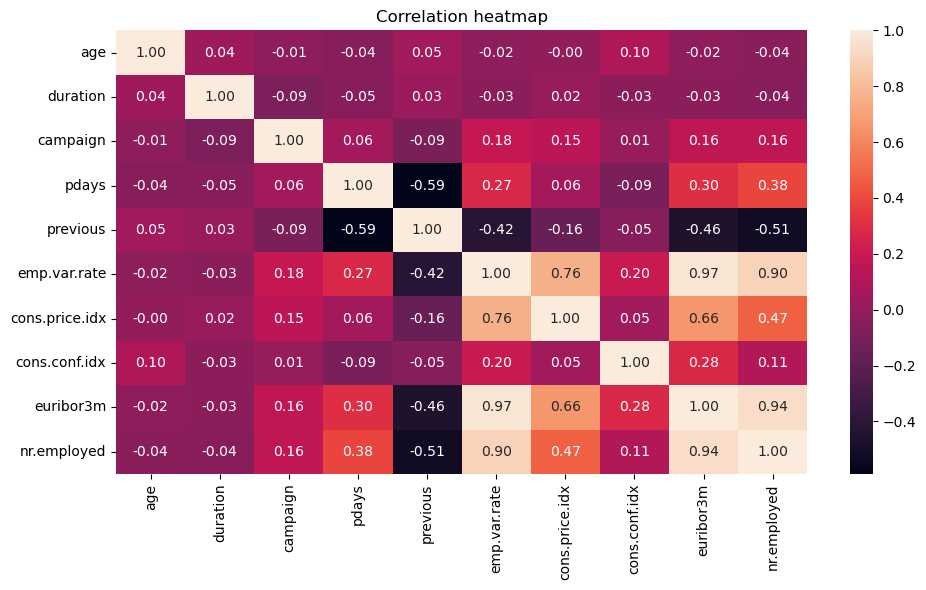

In [52]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [45]:
import sklearn
print(sklearn.__version__)

1.7.2


In [54]:
#b
from sklearn.preprocessing import LabelEncoder, StandardScaler

# One-hot encode categorical columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("y")  # keep target separate
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Label encode target variable y
df_encoded["y"] = (df["y"] == "yes").astype(int)

# Standardize numeric columns
scaler = StandardScaler()
numeric_cols = ["age", "duration", "campaign", "pdays", "previous",
                "emp.var.rate", "cons.price.idx", "cons.conf.idx",
                "euribor3m", "nr.employed"]

df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

display(df_encoded.head())
print(df_encoded.shape)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,-0.980752,0.903952,-0.209228,0.201031,-0.351356,-1.206054,-1.185448,-1.240939,-1.331707,-0.914779,...,False,False,True,False,False,False,False,False,True,False
1,-0.107991,0.350300,0.569634,0.201031,-0.351356,0.649441,0.715193,0.892269,0.711698,0.332862,...,False,False,True,False,False,False,False,False,True,False
2,-1.465619,-0.116966,-0.598660,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.773427,0.836535,...,False,False,False,False,False,False,True,False,True,False
3,-0.204965,-0.941553,0.180203,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.771697,0.836535,...,False,False,True,False,False,False,False,False,True,False
4,0.667795,-0.780563,-0.598660,0.201031,-0.351356,-0.118350,-0.655478,-0.326707,0.328632,0.398028,...,False,False,False,True,False,False,False,False,True,False


(4119, 64)


In [55]:
#c
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score

# To the best of my knowledge this is a classification task
# Chosen models:
# 1. SVC: Good for binary classification, handles class imbalance with class_weight
# 2. Random Forest: Handles mixed data pretty well
# 3. Gradient Boosting: Good with tabular data

# Set up X and y
y = df_encoded["y"]
X = df_encoded.drop(columns=["y"])

# Train-validation-test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# SVM with GridSearch
param_grid_svm = {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1], "kernel": ["rbf"]}
grid_svm = GridSearchCV(SVC(random_state=42, class_weight="balanced"), param_grid_svm, cv=5, scoring="recall", n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best SVM params:", grid_svm.best_params_)
print("SVM Validation Recall:", f"{recall_score(y_val, grid_svm.best_estimator_.predict(X_val)):.4f}")

# Random Forest with GridSearch
param_grid_rf = {"n_estimators": [100, 200], "max_depth": [5, 10, None], "bootstrap": [True, False]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring="recall", n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Best RF params:", grid_rf.best_params_)
print("RF Validation Recall:", f"{recall_score(y_val, grid_rf.best_estimator_.predict(X_val)):.4f}")

# Gradient Boosting with GridSearch
param_grid_gb = {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring="recall", n_jobs=-1)
grid_gb.fit(X_train, y_train)
print("Best GB params:", grid_gb.best_params_)
print("GB Validation Recall:", f"{recall_score(y_val, grid_gb.best_estimator_.predict(X_val)):.4f}")

Best SVM params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Validation Recall: 0.8936
Best RF params: {'bootstrap': False, 'max_depth': None, 'n_estimators': 100}
RF Validation Recall: 0.3404
Best GB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
GB Validation Recall: 0.4787


In [56]:
#d
from sklearn.model_selection import cross_val_score

# Train/val/test split results (from above)
print("=== Train/Val/Test Split ===")
for name, grid in [("SVM", grid_svm), ("Random Forest", grid_rf), ("Gradient Boosting", grid_gb)]:
    score = recall_score(y_val, grid.best_estimator_.predict(X_val))
    print(f"{name} Validation Recall: {score:.4f}")

# Cross-validation on full train+val set
print("\n=== Cross-Validation (5-fold) ===")
X_cv = pd.concat([X_train, X_val])
y_cv = pd.concat([y_train, y_val])

for name, grid in [("SVM", grid_svm), ("Random Forest", grid_rf), ("Gradient Boosting", grid_gb)]:
    cv_scores = cross_val_score(grid.best_estimator_, X_cv, y_cv, cv=5, scoring="recall")
    print(f"{name} CV Recall: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

=== Train/Val/Test Split ===
SVM Validation Recall: 0.8936
Random Forest Validation Recall: 0.3404
Gradient Boosting Validation Recall: 0.4787

=== Cross-Validation (5-fold) ===
SVM CV Recall: 0.8802 (+/- 0.0461)
Random Forest CV Recall: 0.3874 (+/- 0.0710)
Gradient Boosting CV Recall: 0.5098 (+/- 0.0186)


--- SVM ---
Accuracy:  0.8325
Precision: 0.3861
Recall:    0.8478
F1-score:  0.5306

--- Random Forest ---
Accuracy:  0.8932
Precision: 0.5400
Recall:    0.2935
F1-score:  0.3803

--- Gradient Boosting ---
Accuracy:  0.8908
Precision: 0.5135
Recall:    0.4130
F1-score:  0.4578



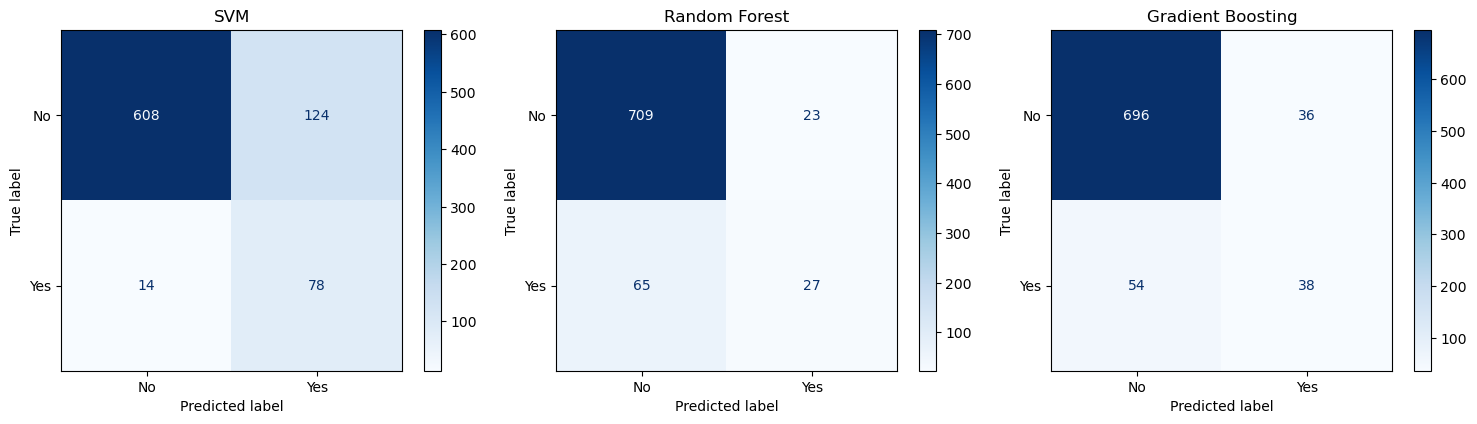

In [58]:
#e
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = [("SVM", grid_svm), ("Random Forest", grid_rf), ("Gradient Boosting", grid_gb)]

for name, grid in models:
    y_pred = grid.best_estimator_.predict(X_test)
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.4f}\n")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, grid) in zip(axes, models):
    y_pred = grid.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues")
    ax.set_title(f"{name}")
plt.tight_layout()
plt.show()

In my limited knowledge Recall is the most important metric here, so according to that SVM takes the cake here

### *AI Usage*
AI was used in some tasks, mostly improving code and some generated code. Sadly had to use AI a bit more than I would have liked on task 3